In [1]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import pandas as pds
import matplotlib.pyplot as plt2025
dataframe = pds.read_csv('https://raw.githubusercontent.com/chihleebobo/0511/main/house.csv')
print(dataframe.head())

           id        date     price  bedrooms  bathrooms  sqft_living  \
0  7129300520  10/13/2014  221900.0         3       1.00         1180   
1  6414100192   12/9/2014  538000.0         3       2.25         2570   
2  5631500400   2/25/2015  180000.0         2       1.00          770   
3  2487200875   12/9/2014  604000.0         4       3.00         1960   
4  1954400510   2/18/2015  510000.0         3       2.00         1680   

   sqft_lot  floors  waterfront  view  ...  grade  sqft_above  sqft_basement  \
0      5650     1.0           0     0  ...      7        1180              0   
1      7242     2.0           0     0  ...      7        2170            400   
2     10000     1.0           0     0  ...      6         770              0   
3      5000     1.0           0     0  ...      7        1050            910   
4      8080     1.0           0     0  ...      8        1680              0   

   yr_built  yr_renovated  zipcode      lat     long  sqft_living15  \
0      19

In [2]:
print(dataframe.isnull().values.sum())
print("本資料中，有多少筆資料:", dataframe.shape)
print("excel中之欄位名稱，分別為:", dataframe.keys())
print("本資料中第一筆之內容:", dataframe.iloc[0,:])
print("本資料中第一筆之預測目標:",dataframe['price'][0])

0
本資料中，有多少筆資料: (21597, 21)
excel中之欄位名稱，分別為: Index(['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living',
       'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'sqft_living15', 'sqft_lot15'],
      dtype='object')
本資料中第一筆之內容: id               7129300520
date             10/13/2014
price              221900.0
bedrooms                  3
bathrooms               1.0
sqft_living            1180
sqft_lot               5650
floors                  1.0
waterfront                0
view                      0
condition                 3
grade                     7
sqft_above             1180
sqft_basement             0
yr_built               1955
yr_renovated              0
zipcode               98178
lat                 47.5112
long               -122.257
sqft_living15          1340
sqft_lot15             5650
Name: 0, dtype: object
本資料中第一筆之預測目標: 221900.0


/tmp/ipykernel_474/1516403974.py:1: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  dataframe.age = 2026 - dataframe.yr_built


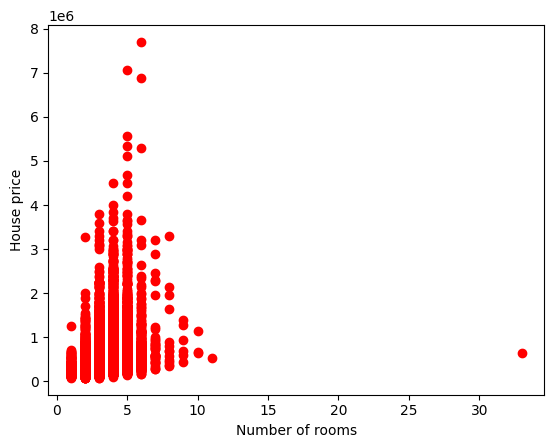

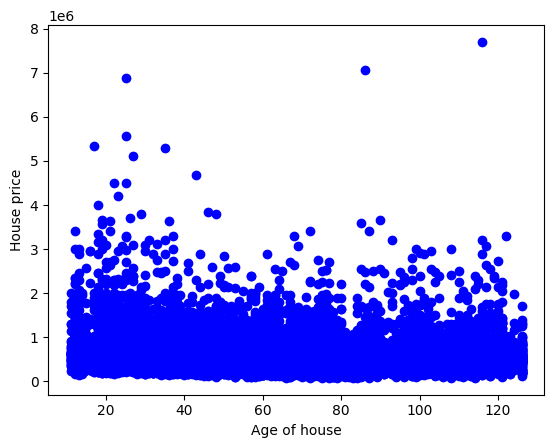

In [3]:
dataframe.age = 2026 - dataframe.yr_built
plt2025.scatter(dataframe.bedrooms, dataframe.price,  color='red')
plt2025.xlabel("Number of rooms")
plt2025.ylabel("House price")
plt2025.show()
plt2025.scatter(dataframe.age, dataframe.price,  color='blue')
plt2025.xlabel("Age of house")
plt2025.ylabel("House price")
plt2025.show()

In [4]:
x = dataframe.drop(['price','id','date','yr_built','zipcode','lat','long'],axis=1)
y = dataframe['price']/10000
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print("原始資料庫的維度分別是:", dataframe.shape)
print("訓練集的維度大小:   ", x_train.shape)
print("測試集的維度大小:   ", x_test.shape)

原始資料庫的維度分別是: (21597, 21)
訓練集的維度大小:    (17277, 14)
測試集的維度大小:    (4320, 14)


In [5]:
model0330 = LinearRegression()
model0330.fit(x_train, y_train)
print ('係數_Coefficients: ', model0330.coef_)
print ('截距_Intercept: ',model0330.intercept_)

係數_Coefficients:  [-3.78781857e+00 -1.52864509e+00  1.32665058e-02 -6.70149400e-07
  3.31320065e-02  5.60464239e+01  5.59216385e+00  6.02040596e+00
  1.03865655e+01  4.93186184e-03  8.33464398e-03  7.30975626e-03
  1.78478257e-03 -8.14708424e-05]
截距_Intercept:  -73.70388037003809


In [6]:
predict_0330 = model0330.predict(x_test)
score0330 = mean_squared_error(predict_0330, y_test)
print("Mean_Square_Error: ", score0330)

Mean_Square_Error:  522.1628411374477
